In [6]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib kagglehub

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset Path:
/kaggle/input/telco-customer-churn

Files:
['WA_Fn-UseC_-Telco-Customer-Churn.csv']

First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service        

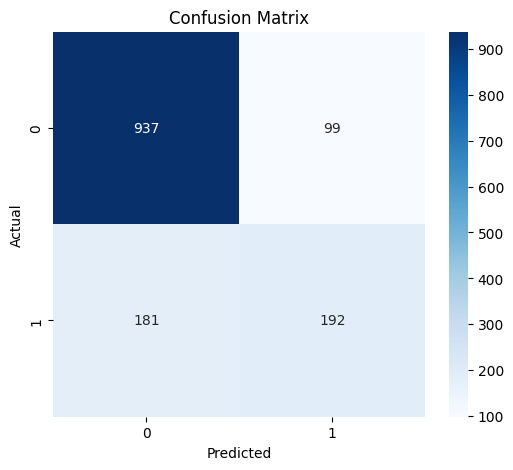


Pipeline Saved Successfully!

Prediction for Sample Customer:
Customer Will Churn


In [7]:
# ==========================================================
# ADVANCED TASK 2 - END-TO-END ML PIPELINE
# CUSTOMER CHURN PREDICTION
# ==========================================================

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# DOWNLOAD DATASET
# ==========================================================

path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)

print("Dataset Path:")
print(path)

print("\nFiles:")
print(os.listdir(path))

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv(
    os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
)

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

# ==========================================================
# HANDLE TOTALCHARGES COLUMN
# ==========================================================

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# ==========================================================
# REMOVE CUSTOMER ID
# ==========================================================

df = df.drop("customerID", axis=1)

# ==========================================================
# TARGET VARIABLE ENCODING
# ==========================================================

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop("Churn", axis=1)

y = df["Churn"]

# ==========================================================
# IDENTIFY COLUMN TYPES
# ==========================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

# ==========================================================
# NUMERIC PIPELINE
# ==========================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# ==========================================================
# CATEGORICAL PIPELINE
# ==========================================================

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# ==========================================================
# PREPROCESSOR
# ==========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ==========================================================
# COMPLETE PIPELINE
# ==========================================================

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier())
    ]
)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# HYPERPARAMETER TUNING
# ==========================================================

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [5, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

# ==========================================================
# TRAIN MODEL
# ==========================================================

print("\nTraining Model...\n")

grid_search.fit(X_train, y_train)

# ==========================================================
# BEST MODEL
# ==========================================================

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

# ==========================================================
# PREDICTIONS
# ==========================================================

y_pred = best_model.predict(X_test)

# ==========================================================
# EVALUATION
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# SAVE COMPLETE PIPELINE
# ==========================================================

joblib.dump(
    best_model,
    "customer_churn_pipeline.pkl"
)

print("\nPipeline Saved Successfully!")

# ==========================================================
# TEST NEW CUSTOMER
# ==========================================================

sample_customer = X_test.iloc[[0]]

prediction = best_model.predict(sample_customer)

print("\nPrediction for Sample Customer:")

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Stay")